In [2]:
# Data Wrangling
import numpy as np
import pandas as pd
import unicodedata
import re

import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler

In [3]:


def calcular_woe_iv(df:pd.DataFrame, target:str):
    """
    Descripción: 
        Calcula Weight of Evidence (WoE) e Information Value (IV) para todas 
        las variables categóricas en un DataFrame.

    Parámetros

    df : pandas.DataFrame
            Conjunto de datos que contiene variables categóricas y la variable objetivo.
    target : str
            Nombre de la columna objetivo binaria (0 = bueno, 1 = malo).

    Retorno

    woe_df : pandas.DataFrame
        DataFrame con columnas: ['variable', 'categoria', 'WoE'] 

    iv_df : pandas.DataFrame
        DataFrame con columnas: ['variable', 'IV']
    """
    cat_vars = df.select_dtypes(include=['object', 'category']).columns
    ## num_vars = df.columns.drop('target')
    
    woe_rows = []   
    iv_rows = []   
    for var in cat_vars:
     
        tbl = df.groupby(var)[target].agg(['count', 'sum'])
        tbl.columns = ['total', 'malos']
        tbl['buenos'] = tbl['total'] - tbl['malos']

        pct_b = tbl['buenos'] / tbl['buenos'].sum()
        pct_m = tbl['malos']  / tbl['malos'].sum()

        tbl['WoE']  = np.log(pct_b / pct_m)
        tbl['IV_i'] = (pct_b - pct_m) * tbl['WoE']

        for categoria, fila in tbl.iterrows():
            woe_rows.append([var, categoria, fila['WoE']])

        iv_rows.append([var, tbl['IV_i'].sum()])


    woe_df = pd.DataFrame(woe_rows, columns=['variable', 'categoria', 'WoE'])

    iv_df = pd.DataFrame(iv_rows, columns=['variable', 'IV']).sort_values('IV', ascending=False)

    return woe_df, iv_df


In [4]:
def freq_discrete(df, features):
    """
    Calcula y muestra tablas de frecuencias absolutas, relativas y acumuladas para variables categóricas.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que contiene las variables a analizar.
    features : list of str
        Lista con los nombres de las columnas categóricas a analizar.

    Descripción
    -----------
    Para cada variable en `features`, imprime su nombre y muestra una tabla con:
      - Frecuencia absoluta de cada categoría.
      - Frecuencia relativa (porcentaje) de cada categoría.
      - Frecuencia absoluta acumulada.
      - Frecuencia relativa acumulada.
    Los valores se formatean para mejor visualización.

    Ejemplo
    -------
    freq_discrete(df, ["color", "country"])
    """
    for feature in features:
        print(f"Feature: {feature}")
        abs_series = df[feature].value_counts(dropna=False)
        rel_series = df[feature].value_counts(dropna=False, normalize=True)
        freq = pd.DataFrame({"Absolute frequency": abs_series, "Relative frequency": rel_series})
        freq["Accumulated frequency"] = freq["Absolute frequency"].cumsum()
        freq["Accumulated %"] = freq["Relative frequency"].cumsum()
        freq["Absolute frequency"] = freq["Absolute frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Relative frequency"] = freq["Relative frequency"].map(lambda x: "{:,.2%}".format(x))
        freq["Accumulated frequency"] = freq["Accumulated frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Accumulated %"] = freq["Accumulated %"].map(lambda x: "{:,.2%}".format(x))
        display(freq)

In [ ]:
def normalizar_columnas(df):
    

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .map(lambda x: unicodedata.normalize('NFKD', x)
             .encode('ascii', 'ignore')
             .decode('utf-8'))
        .str.replace(r'[^a-z0-9_ ]', '', regex=True)
        .str.replace(' ', '_')
    )
    for col in df.select_dtypes(include='object').columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(lambda x: unicodedata.normalize('NFKD', x)
                 .encode('ascii', 'ignore')
                 .decode('utf-8'))
        )

    return df


### Lectura del Archivo y Analisis Exploratorio

In [6]:
data=r'/home/eduardo-castillo/Documentos/diplomado/repositorio/Diplomado_DataSciene/practicas/modelos_supervisados/Team calor o team frío.xlsx'

df=pd.read_excel(data)
df.head()

,Marca temporal,Color primario favorito,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Tipo de personalidad,Número de vasos de agua que tomas al día (numérico),¿Día o noche?,Actividad física,Mascota favorita,¿Chile del que pica o del que no pica?,Número de hermanos (numérica),¿Las quesadillas van con queso?,Número de tatuajes (numérica),¿Team frío o team calor?
0,2024-03-16 10:04:41.993000,Azul,29,1.92,107,Introvertido,6,Noche,¿Qué es eso?,Perrro,Del que pica,2,Con queso,0,NaN
1,2024-03-16 10:04:42.278000,Azul,26,1.57,58,Introvertido,5,Noche,¿Qué es eso?,Perrro,Del que pica,0,Con queso,0,NaN
2,2024-03-16 10:04:48.547000,Azul,25,1.71,78,Introvertido,3,Noche,Si,Perrro,Del que pica,1,Con queso,0,NaN
3,2024-03-16 10:04:51.113000,Rojo,27,1.78,87,Introvertido,4,Noche,¿Qué es eso?,Perrro,Del que pica,1,Sin queso,0,NaN
4,2024-03-16 10:04:56.252000,Azul,23,1.7,76,Introvertido,4,Noche,Si,Gato,Del que no pica,2,Con queso,0,NaN


In [7]:
### Normalizacion de columnnas 

df = normalizar_columnas(df)
df.head()

,marca_temporal,color_primario_favorito,edad_en_anos_numerica,estatura_en_metros_numerica,peso_en_kg_numerica,tipo_de_personalidad,numero_de_vasos_de_agua_que_tomas_al_dia_numerico,dia_o_noche,actividad_fisica,mascota_favorita,chile_del_que_pica_o_del_que_no_pica,numero_de_hermanos_numerica,las_quesadillas_van_con_queso,numero_de_tatuajes_numerica,team_frio_o_team_calor
0,2024-03-16 10:04:41.993000,azul,29,1.92,107,introvertido,6,noche,que es eso?,perrro,del que pica,2,con queso,0,nan
1,2024-03-16 10:04:42.278000,azul,26,1.57,58,introvertido,5,noche,que es eso?,perrro,del que pica,0,con queso,0,nan
2,2024-03-16 10:04:48.547000,azul,25,1.71,78,introvertido,3,noche,si,perrro,del que pica,1,con queso,0,nan
3,2024-03-16 10:04:51.113000,rojo,27,1.78,87,introvertido,4,noche,que es eso?,perrro,del que pica,1,sin queso,0,nan
4,2024-03-16 10:04:56.252000,azul,23,1.7,76,introvertido,4,noche,si,gato,del que no pica,2,con queso,0,nan


In [8]:
## Validamos vacios 
df.isnull().sum()

marca_temporal                                       0
color_primario_favorito                              0
edad_en_anos_numerica                                0
estatura_en_metros_numerica                          0
peso_en_kg_numerica                                  0
tipo_de_personalidad                                 0
numero_de_vasos_de_agua_que_tomas_al_dia_numerico    0
dia_o_noche                                          0
actividad_fisica                                     0
mascota_favorita                                     0
chile_del_que_pica_o_del_que_no_pica                 0
numero_de_hermanos_numerica                          0
las_quesadillas_van_con_queso                        0
numero_de_tatuajes_numerica                          0
team_frio_o_team_calor                               0
dtype: int64

In [9]:
### Estructura de cada valor de cada columna 

freq_discrete(df,df.columns)

Feature: marca_temporal


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
marca_temporal,,,,
26/6/2025 18:10:41,2,0.97%,2,0.97%
2024-03-16 10:04:41.993000,1,0.48%,3,1.45%
2024-03-16 10:04:48.547000,1,0.48%,4,1.93%
2024-03-16 10:04:51.113000,1,0.48%,5,2.42%
2024-03-16 10:04:56.252000,1,0.48%,6,2.90%
...,...,...,...,...
2026-01-08 18:17:46.615000,1,0.48%,203,98.07%
2026-01-08 18:18:26.748000,1,0.48%,204,98.55%
2026-01-08 18:25:02.075000,1,0.48%,205,99.03%


Feature: color_primario_favorito


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
color_primario_favorito,,,,
azul,112,54.11%,112,54.11%
rojo,45,21.74%,157,75.85%
amarillo,14,6.76%,171,82.61%
verde,14,6.76%,185,89.37%
negro,6,2.90%,191,92.27%
morado,3,1.45%,194,93.72%
rosa,2,0.97%,196,94.69%
naranja,1,0.48%,197,95.17%
oro rosa,1,0.48%,198,95.65%


Feature: edad_en_anos_numerica


...

,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
las_quesadillas_van_con_queso,,,,
con queso,156,75.36%,156,75.36%
sin queso,51,24.64%,207,100.00%


Feature: numero_de_tatuajes_numerica


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
numero_de_tatuajes_numerica,,,,
0,158,76.33%,158,76.33%
2,16,7.73%,174,84.06%
1,12,5.80%,186,89.86%
3,4,1.93%,190,91.79%
5,4,1.93%,194,93.72%
6,3,1.45%,197,95.17%
4,3,1.45%,200,96.62%
8,2,0.97%,202,97.58%
cero,1,0.48%,203,98.07%


Feature: team_frio_o_team_calor


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
team_frio_o_team_calor,,,,
team frio,160,77.29%,160,77.29%
team calor,33,15.94%,193,93.24%
nan,14,6.76%,207,100.00%


In [10]:
## Porcentaje de Valores Faltantes 

(df.isna().mean() * 100).round(2)


marca_temporal                                       0.0
color_primario_favorito                              0.0
edad_en_anos_numerica                                0.0
estatura_en_metros_numerica                          0.0
peso_en_kg_numerica                                  0.0
tipo_de_personalidad                                 0.0
numero_de_vasos_de_agua_que_tomas_al_dia_numerico    0.0
dia_o_noche                                          0.0
actividad_fisica                                     0.0
mascota_favorita                                     0.0
chile_del_que_pica_o_del_que_no_pica                 0.0
numero_de_hermanos_numerica                          0.0
las_quesadillas_van_con_queso                        0.0
numero_de_tatuajes_numerica                          0.0
team_frio_o_team_calor                               0.0
dtype: float64

In [11]:
df['mascota_favorita'].value_counts()

mascota_favorita
perro             65
perrro            53
gato              47
perros            12
gatos              6
otros              4
peroo              2
dalmata            1
monos              1
-                  1
dragon             1
perritos           1
cats               1
perros y gatos     1
nan                1
michi              1
canino             1
ninguna            1
mariposa           1
perro y gato       1
gato y  perro      1
s                  1
peces              1
na                 1
piedra             1
Name: count, dtype: int64

In [12]:
### Limpieza y Transformacion de los datos 

df['mascota_favorita'] = (
    df['mascota_favorita']
    .str.lower()
    .str.strip()
    .replace({
        'dalmata':'perro',
        'canino':'perro',
        'cats': 'gato',
        'gatos': 'perro',
        'perros y gatos': 'perro y gato',
        'gato y  perro': 'perro y gato',
        'michi':'gato',
        'perritos':'perro',
        '-':'ninguna',
        's':'ninguna',
        'na':'ninguna',
        'nan':'ninguna',
        'piedra':'ninguna'

    })
)


df['mascota_favorita'] = (
    df['mascota_favorita']
    .str.lower()
    .str.strip()
    .replace(
        r'^per+r*o+(?:itos|s)?$',
        'perro',
        regex=True
    )
)
## Eliminamos las columnas que contengan x ya que no podemos inferrir su valor 
df = df[~(df == 'x').any(axis=1)]

### Limpieza de cada columna del df 
df['numero_de_vasos_de_agua_que_tomas_al_dia_numerico']=df['numero_de_vasos_de_agua_que_tomas_al_dia_numerico'].astype(str).str.strip().str.replace('2 vasotes', '25', regex=False).str.strip().str.replace('10+', '10', regex=False).str.replace('diez', '10', regex=False)
df['numero_de_hermanos_numerica']=df['numero_de_hermanos_numerica'].astype(str).str.strip().str.replace('una', '1', regex=False).str.strip().str.replace('x', '0', regex=False)
df['numero_de_tatuajes_numerica']=df['numero_de_tatuajes_numerica'].astype(str).str.strip().str.replace('cero', '0', regex=False).str.replace('no', '0', regex=False).str.replace('x', '0', regex=False)

df['estatura_en_metros_numerica']=df['estatura_en_metros_numerica'].astype(str).str.extract(r'(\d+\.?\d*)')
cols=['numero_de_vasos_de_agua_que_tomas_al_dia_numerico' ,'numero_de_hermanos_numerica','numero_de_tatuajes_numerica','estatura_en_metros_numerica' ]
df[cols] = df[cols].astype(float)
df['edad_en_anos_numerica']=df['edad_en_anos_numerica'].astype(str).str.strip().str.replace('veinticinco', '25', regex=False).astype('Float32')
df['numero_de_vasos_de_agua_que_tomas_al_dia_numerico']=df['numero_de_vasos_de_agua_que_tomas_al_dia_numerico'].astype(str).str.strip().str.replace('2 vasotes', '2', regex=False).astype('Float32')

df['peso_en_kg_numerica'] = (df['peso_en_kg_numerica'].astype(str).str.extract(r'(\d+)')[0])
df['peso_en_kg_numerica'] = df['peso_en_kg_numerica'].astype('Float32')

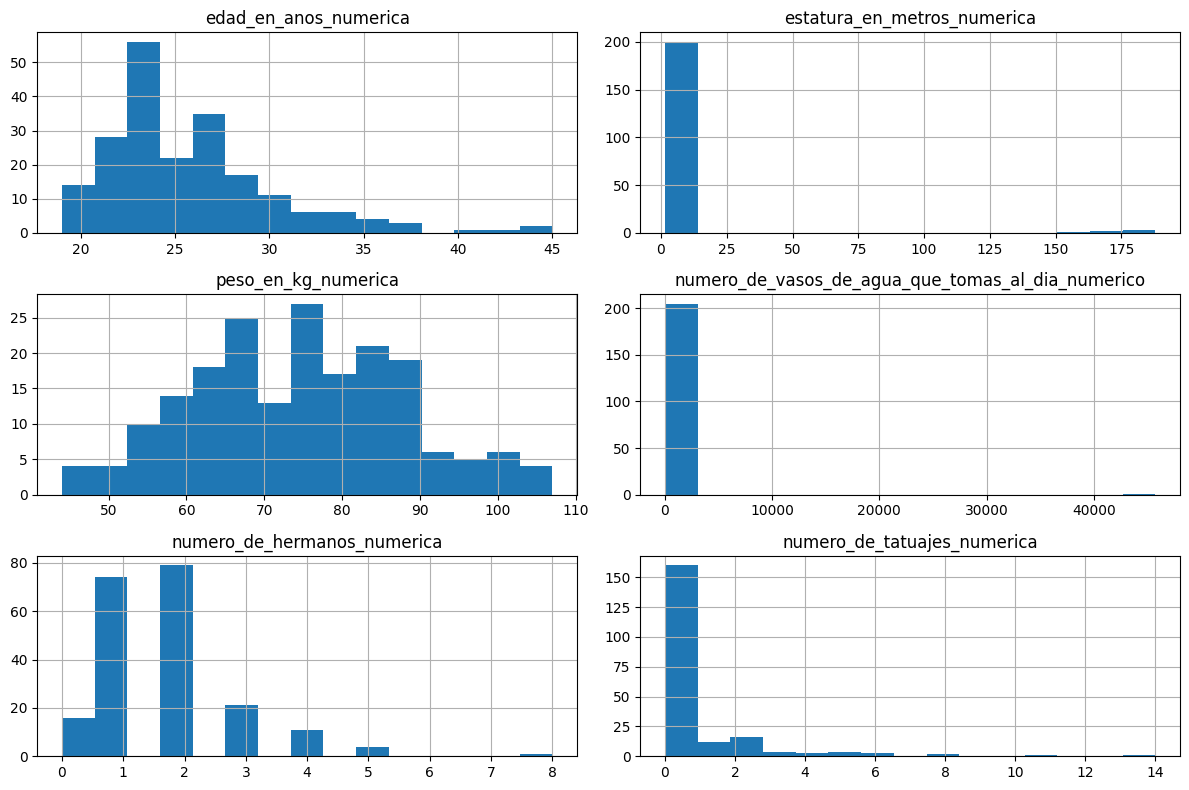

In [13]:
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols].hist(figsize=(12,8), bins=15)
plt.tight_layout()
plt.show()


In [14]:
### nos percatamos que tenemos presencia de dos outliers  en estatura en metros, y en numero de vasos 

## outlier para la variable de vasos de agua =45752
### 160 el problema de la variable de estatura algunos estan escritas en cm 


### Validamos que todos esten en metros 


def normalizar_estatura(x):
    if pd.isna(x):
        return np.nan
    # Si el valor es mayor a 3, se asume centímetros (ej: 172, 183, 150)
    if x > 3:
        return x / 100
    # Si es menor o igual a 3, ya está en metros (ej: 1.72, 1.83)
    return x


df['estatura_en_metros_numerica'] = df['estatura_en_metros_numerica'].apply(normalizar_estatura)



In [15]:
df.head()

,marca_temporal,color_primario_favorito,edad_en_anos_numerica,estatura_en_metros_numerica,peso_en_kg_numerica,tipo_de_personalidad,numero_de_vasos_de_agua_que_tomas_al_dia_numerico,dia_o_noche,actividad_fisica,mascota_favorita,chile_del_que_pica_o_del_que_no_pica,numero_de_hermanos_numerica,las_quesadillas_van_con_queso,numero_de_tatuajes_numerica,team_frio_o_team_calor
0,2024-03-16 10:04:41.993000,azul,29.0,1.92,107.0,introvertido,6.0,noche,que es eso?,perro,del que pica,2.0,con queso,0.0,nan
1,2024-03-16 10:04:42.278000,azul,26.0,1.57,58.0,introvertido,5.0,noche,que es eso?,perro,del que pica,0.0,con queso,0.0,nan
2,2024-03-16 10:04:48.547000,azul,25.0,1.71,78.0,introvertido,3.0,noche,si,perro,del que pica,1.0,con queso,0.0,nan
3,2024-03-16 10:04:51.113000,rojo,27.0,1.78,87.0,introvertido,4.0,noche,que es eso?,perro,del que pica,1.0,sin queso,0.0,nan
4,2024-03-16 10:04:56.252000,azul,23.0,1.70,76.0,introvertido,4.0,noche,si,gato,del que no pica,2.0,con queso,0.0,nan


In [16]:
## No hay columnas que tengan mas del 30 % de valores ausentes 
ls_missing = [x for x, y in df.isna().mean().items() if y > 0.3]
ls_missing

[]

In [17]:
### Variables unarias 

### No tenemos variables unarias 
df.nunique()


marca_temporal                                       205
color_primario_favorito                               18
edad_en_anos_numerica                                 24
estatura_en_metros_numerica                           38
peso_en_kg_numerica                                   51
tipo_de_personalidad                                   2
numero_de_vasos_de_agua_que_tomas_al_dia_numerico     15
dia_o_noche                                            2
actividad_fisica                                       3
mascota_favorita                                       9
chile_del_que_pica_o_del_que_no_pica                   2
numero_de_hermanos_numerica                            7
las_quesadillas_van_con_queso                          2
numero_de_tatuajes_numerica                           10
team_frio_o_team_calor                                 3
dtype: int64

### Deteccion de Outliers

In [18]:
import numpy as np


### Como el dataset es muy peque;o remplazamos los valores extremos 
# Limites 5% y 95%
q_low = df['peso_en_kg_numerica'].quantile(0.05)
q_high = df['peso_en_kg_numerica'].quantile(0.95)

df['peso_en_kg_numerica'] = df['peso_en_kg_numerica'].clip(lower=q_low, upper=q_high)


q_low = df['edad_en_anos_numerica'].quantile(0.05)
q_high = df['edad_en_anos_numerica'].quantile(0.95)

df['edad_en_anos_numerica'] = df['edad_en_anos_numerica'].clip(lower=q_low, upper=q_high)



q_low = df['numero_de_vasos_de_agua_que_tomas_al_dia_numerico'].quantile(0.05)
q_high = df['numero_de_vasos_de_agua_que_tomas_al_dia_numerico'].quantile(0.95)

df['numero_de_vasos_de_agua_que_tomas_al_dia_numerico'] = df['numero_de_vasos_de_agua_que_tomas_al_dia_numerico'].clip(lower=q_low, upper=q_high)




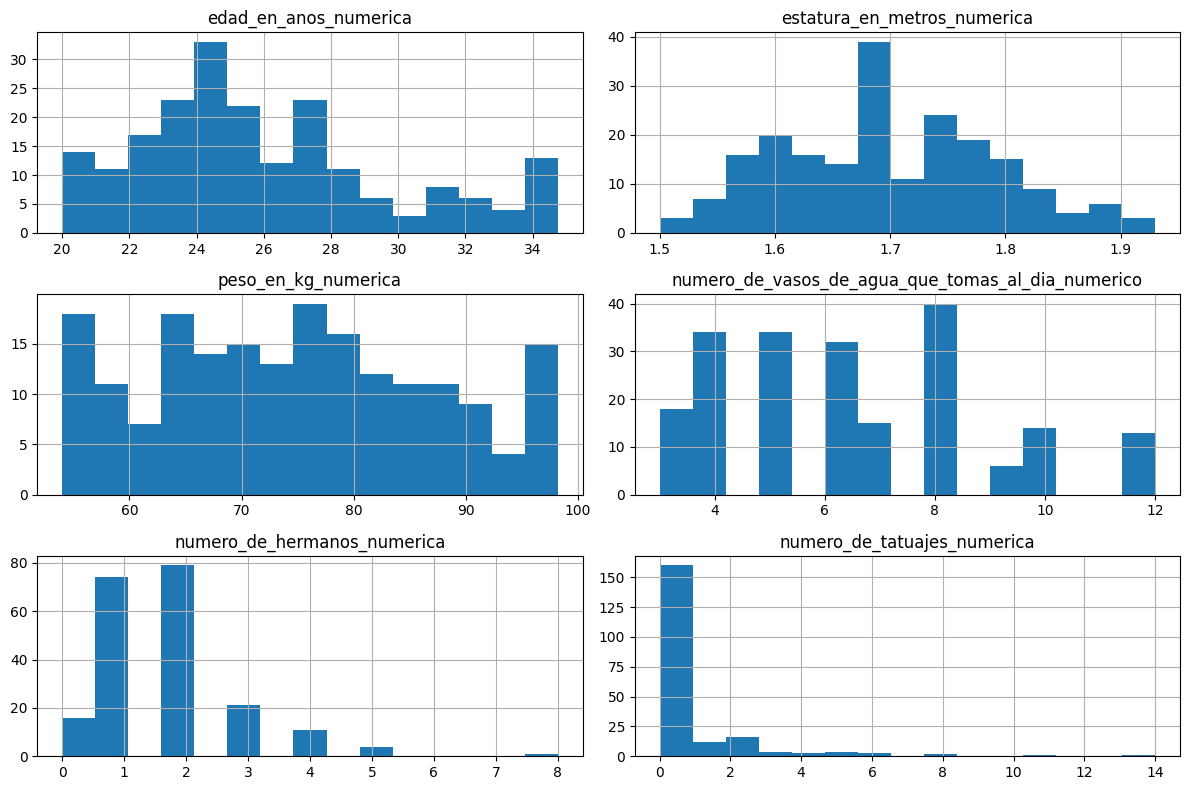

In [19]:
### Validamos el tratamiento de  outliers

num_cols = df.select_dtypes(include=['number']).columns
df[num_cols].hist(figsize=(12,8), bins=15)
plt.tight_layout()
plt.show()

In [20]:
df.drop(columns='marca_temporal',inplace=True)

In [21]:
### Analisis de VAriables Categoricas 

cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

for c in cat_cols:
    print(f"\nFrecuencias de {c}:")
    print(df[c].value_counts(dropna=False))


Frecuencias de color_primario_favorito:
color_primario_favorito
azul           112
rojo            45
amarillo        14
verde           14
negro            5
morado           3
rosa             2
naranja          1
oro rosa         1
mostaza          1
azul marino      1
azul cielo       1
gris             1
rojo y azul      1
granate          1
lila             1
purpura          1
cian             1
Name: count, dtype: int64

Frecuencias de tipo_de_personalidad:
tipo_de_personalidad
introvertido    127
extrovertido     79
Name: count, dtype: int64

Frecuencias de dia_o_noche:
dia_o_noche
noche    138
dia       68
Name: count, dtype: int64

Frecuencias de actividad_fisica:
actividad_fisica
si             162
que es eso?     34
no              10
Name: count, dtype: int64

Frecuencias de mascota_favorita:
mascota_favorita
perro           141
gato             49
ninguna           5
otros             4
perro y gato      3
dragon            1
monos             1
mariposa          1
pece

### valores Ausentes 

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 0 to 206
Data columns (total 14 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   color_primario_favorito                            206 non-null    object 
 1   edad_en_anos_numerica                              206 non-null    Float32
 2   estatura_en_metros_numerica                        206 non-null    float64
 3   peso_en_kg_numerica                                193 non-null    Float32
 4   tipo_de_personalidad                               206 non-null    object 
 5   numero_de_vasos_de_agua_que_tomas_al_dia_numerico  206 non-null    Float32
 6   dia_o_noche                                        206 non-null    object 
 7   actividad_fisica                                   206 non-null    object 
 8   mascota_favorita                                   206 non-null    object 
 9   chile_del_que_p

In [23]:
#### Trabajamos los valores Ausentes 
### Como podemos observar los valores ausentes es menor del 10% por lo que podemos imputar sin ningun problema 


### VAriable peso
### Limpiamos la variable para poderla convertirla a numerica


df['peso_en_kg_numerica']=df['peso_en_kg_numerica'].fillna(df['peso_en_kg_numerica'].median())


### Team Frio o Calor 
df['team_frio_o_team_calor'] = df['team_frio_o_team_calor'].replace('nan', np.nan)
df['team_frio_o_team_calor'] = df['team_frio_o_team_calor'].fillna( df['team_frio_o_team_calor'].mode()[0])




### Seleccion de Variables 

In [24]:
data=df.copy()

                                                   edad_en_anos_numerica  \
edad_en_anos_numerica                                           1.000000   
estatura_en_metros_numerica                                     0.130633   
peso_en_kg_numerica                                             0.184734   
numero_de_vasos_de_agua_que_tomas_al_dia_numerico              -0.038121   
numero_de_hermanos_numerica                                     0.105915   
numero_de_tatuajes_numerica                                     0.029462   

                                                   estatura_en_metros_numerica  \
edad_en_anos_numerica                                                 0.130633   
estatura_en_metros_numerica                                           1.000000   
peso_en_kg_numerica                                                   0.814265   
numero_de_vasos_de_agua_que_tomas_al_dia_numerico                    -0.037370   
numero_de_hermanos_numerica                              

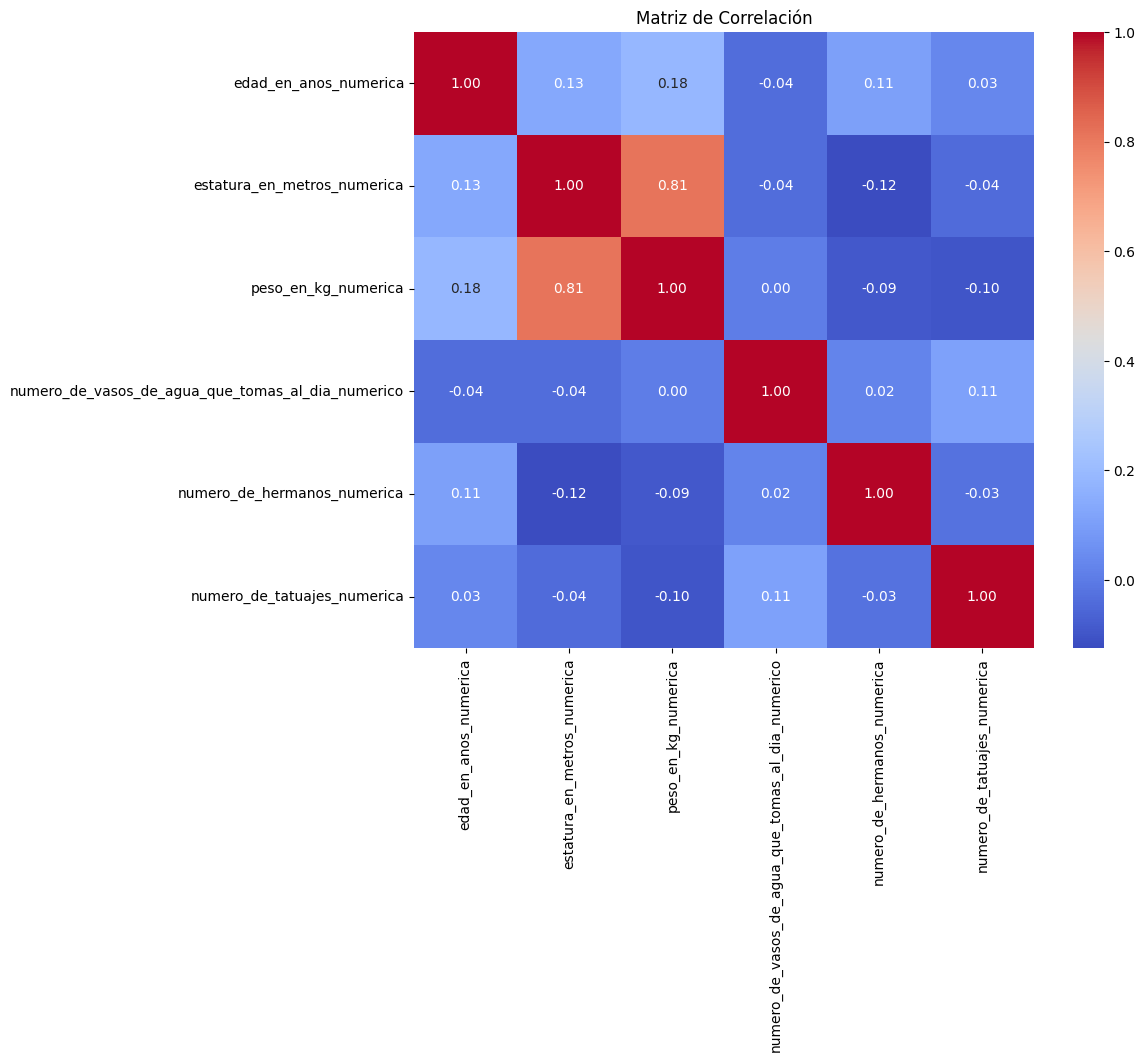

In [25]:

# 3. Calcular matriz de correlación
corr_matrix = df[num_cols].corr()

# 4. Mostrar matriz en consola
print(corr_matrix)

# 5. Visualizar con heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

In [26]:
iv,woe=calcular_woe_iv(df,'estatura_en_metros_numerica')

In [27]:
woe

,variable,IV
0,color_primario_favorito,8.863408e-04
4,mascota_favorita,6.052979e-04
5,chile_del_que_pica_o_del_que_no_pica,1.551782e-04
6,las_quesadillas_van_con_queso,4.428006e-05
2,dia_o_noche,9.020886e-06
3,actividad_fisica,3.584700e-06
7,team_frio_o_team_calor,2.882205e-06
1,tipo_de_personalidad,8.429229e-07


In [28]:
df.columns

Index(['color_primario_favorito', 'edad_en_anos_numerica',
       'estatura_en_metros_numerica', 'peso_en_kg_numerica',
       'tipo_de_personalidad',
       'numero_de_vasos_de_agua_que_tomas_al_dia_numerico', 'dia_o_noche',
       'actividad_fisica', 'mascota_favorita',
       'chile_del_que_pica_o_del_que_no_pica', 'numero_de_hermanos_numerica',
       'las_quesadillas_van_con_queso', 'numero_de_tatuajes_numerica',
       'team_frio_o_team_calor'],
      dtype='object')

In [29]:
### Eliminamos Variables con Bajo valor predictivo 
#df.drop(columns=['las_quesadillas_van_con_queso','team_frio_o_team_calor','tipo_de_personalidad','las_quesadillas_van_con_queso','dia_o_noche','actividad_fisica'],inplace=True)

In [30]:
cat=[ 'color_primario_favorito','mascota_favorita','chile_del_que_pica_o_del_que_no_pica','tipo_de_personalidad','dia_o_noche','actividad_fisica','las_quesadillas_van_con_queso','team_frio_o_team_calor']

df = pd.get_dummies(df, columns=cat, drop_first=True,dtype=int)

In [31]:
df.head()

,edad_en_anos_numerica,estatura_en_metros_numerica,peso_en_kg_numerica,numero_de_vasos_de_agua_que_tomas_al_dia_numerico,numero_de_hermanos_numerica,numero_de_tatuajes_numerica,color_primario_favorito_azul,color_primario_favorito_azul cielo,color_primario_favorito_azul marino,color_primario_favorito_cian,...,mascota_favorita_peces,mascota_favorita_perro,mascota_favorita_perro y gato,chile_del_que_pica_o_del_que_no_pica_del que pica,tipo_de_personalidad_introvertido,dia_o_noche_noche,actividad_fisica_que es eso?,actividad_fisica_si,las_quesadillas_van_con_queso_sin queso,team_frio_o_team_calor_team frio
0,29.0,1.92,98.199997,6.0,2.0,0.0,1,0,0,0,...,0,1,0,1,1,1,1,0,0,1
1,26.0,1.57,58.0,5.0,0.0,0.0,1,0,0,0,...,0,1,0,1,1,1,1,0,0,1
2,25.0,1.71,78.0,3.0,1.0,0.0,1,0,0,0,...,0,1,0,1,1,1,0,1,0,1
3,27.0,1.78,87.0,4.0,1.0,0.0,0,0,0,0,...,0,1,0,1,1,1,1,0,1,1
4,23.0,1.70,76.0,4.0,2.0,0.0,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1


In [32]:


X = df[[x for x in df.columns if x!='estatura_en_metros_numerica']]
y = df['estatura_en_metros_numerica']



In [33]:
df

,edad_en_anos_numerica,estatura_en_metros_numerica,peso_en_kg_numerica,numero_de_vasos_de_agua_que_tomas_al_dia_numerico,numero_de_hermanos_numerica,numero_de_tatuajes_numerica,color_primario_favorito_azul,color_primario_favorito_azul cielo,color_primario_favorito_azul marino,color_primario_favorito_cian,...,mascota_favorita_peces,mascota_favorita_perro,mascota_favorita_perro y gato,chile_del_que_pica_o_del_que_no_pica_del que pica,tipo_de_personalidad_introvertido,dia_o_noche_noche,actividad_fisica_que es eso?,actividad_fisica_si,las_quesadillas_van_con_queso_sin queso,team_frio_o_team_calor_team frio
0,29.0,1.92,98.199997,6.0,2.0,0.0,1,0,0,0,...,0,1,0,1,1,1,1,0,0,1
1,26.0,1.57,58.0,5.0,0.0,0.0,1,0,0,0,...,0,1,0,1,1,1,1,0,0,1
2,25.0,1.71,78.0,3.0,1.0,0.0,1,0,0,0,...,0,1,0,1,1,1,0,1,0,1
3,27.0,1.78,87.0,4.0,1.0,0.0,0,0,0,0,...,0,1,0,1,1,1,1,0,1,1
4,23.0,1.70,76.0,4.0,2.0,0.0,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,24.0,1.60,54.0,6.0,1.0,0.0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1
203,22.0,1.55,71.0,6.0,1.0,5.0,1,0,0,0,...,0,1,0,1,1,1,0,1,1,1
204,32.0,1.60,60.0,4.0,2.0,5.0,0,0,0,0,...,0,0,0,1,1,1,0,1,1,1
205,25.0,1.70,69.0,4.0,2.0,0.0,1,0,0,0,...,0,1,0,1,1,0,0,0,0,1


### Entrenamiento 

In [34]:
# Modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)





kb = SelectKBest(score_func=f_regression, k=12) 
X_train_selected = kb.fit_transform(X_train_scaled, y_train)
X_test_selected = kb.transform(X_test_scaled)




linreg = LinearRegression()
linreg.fit(X_train_selected, y_train)


r2_train = linreg.score(X_train_selected, y_train)
r2_test = linreg.score(X_test_selected, y_test)
print(f"R² train: {r2_train:.4f}, R² test: {r2_test:.4f}")

R² train: 0.6852, R² test: 0.7001


### Metricas de desempeno 





In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predicciones
y_train_pred = linreg.predict(X_train_selected)
y_test_pred = linreg.predict(X_test_selected)

# Métricas en entrenamiento
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)

# Métricas en test
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

# Mostrar resultados
print("==== Métricas del modelo de regresión lineal ====\n")
print("Entrenamiento:")
print(f"R²: {r2_train:.3f}")
print(f"MAE: {mae_train:.3f}")
print(f"MSE: {mse_train:.3f}")
print(f"RMSE: {rmse_train:.3f}\n")

print("Test:")
print(f"R²: {r2_test:.3f}")
print(f"MAE: {mae_test:.3f}")
print(f"MSE: {mse_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")

==== Métricas del modelo de regresión lineal ====

Entrenamiento:
R²: 0.685
MAE: 0.035
MSE: 0.003
RMSE: 0.050

Test:
R²: 0.700
MAE: 0.043
MSE: 0.003
RMSE: 0.055


#### Regresion Logistica

In [36]:
# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
# Model performance
from sklearn.metrics import roc_auc_score

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 0 to 206
Data columns (total 14 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   color_primario_favorito                            206 non-null    object 
 1   edad_en_anos_numerica                              206 non-null    Float32
 2   estatura_en_metros_numerica                        206 non-null    float64
 3   peso_en_kg_numerica                                206 non-null    Float32
 4   tipo_de_personalidad                               206 non-null    object 
 5   numero_de_vasos_de_agua_que_tomas_al_dia_numerico  206 non-null    Float32
 6   dia_o_noche                                        206 non-null    object 
 7   actividad_fisica                                   206 non-null    object 
 8   mascota_favorita                                   206 non-null    object 
 9   chile_del_que_p

In [40]:
data['las_quesadillas_van_con_queso'].unique()

array(['con queso', 'sin queso'], dtype=object)

In [ ]:
## Team frio 0 
## Team Calor 1 

## Calor frio  
# X = df[[x for x in df.columns if x!='team_frio_o_team_calor']]

## Target 

y = df['team_frio_o_team_calor']


KeyError: 'team_frio_o_team_calor'

In [ ]:
logreg = LogisticRegression()


ls_scores = cross_val_score(X=X_train, y=y_train, cv=4, n_jobs=-1, estimator=logreg, scoring="roc_auc")